# ELOM OLUCHI LUCY
# Track: Data Analytics (Oasis Infobyte SIP)
# Task: Level 1 - EDA on Retail Sales

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("retail_sales_dataset.xlsx")
df["Date"] = pd.to_datetime(df["Date"], unit="D", origin="1899-12-30")

print(df.shape)
print(df.dtypes)
print("Missing:", df.isna().sum().sum(), "| Duplicates:", df.duplicated().sum())
print(df["Date"].min(), df["Date"].max())
df.head()

(1000, 9)
Transaction ID              int64
Date                datetime64[s]
Customer ID                   str
Gender                        str
Age                         int64
Product Category              str
Quantity                    int64
Price per Unit              int64
Total Amount                int64
dtype: object
Missing: 0 | Duplicates: 0
2023-01-01 00:00:00 2024-01-01 00:00:00


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [2]:
num_cols = ["Age", "Quantity", "Price per Unit", "Total Amount"]

stats = pd.DataFrame({
    "Mean": df[num_cols].mean(),
    "Median": df[num_cols].median(),
    "Mode": df[num_cols].mode().iloc[0],
    "Std Dev": df[num_cols].std(),
}).round(2)

print(stats)
print("Total revenue:", df["Total Amount"].sum())

                  Mean  Median  Mode  Std Dev
Age              41.39    42.0  43.0    13.68
Quantity          2.51     3.0   4.0     1.13
Price per Unit  179.89    50.0  50.0   189.68
Total Amount    456.00   135.0  50.0   560.00
Total revenue: 456000


*Observations:* Total revenue is 456,000 across 1,000 transactions. The average transaction is 456, but the median is only 135, so a few large purchases pull the average up. Customers are aged 18 to 64 (average 41), and each buys 2.5 items on average.

Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
Freq: M, Name: Total Amount, dtype: int64
Date
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
Freq: Q-DEC, Name: Total Amount, dtype: int64


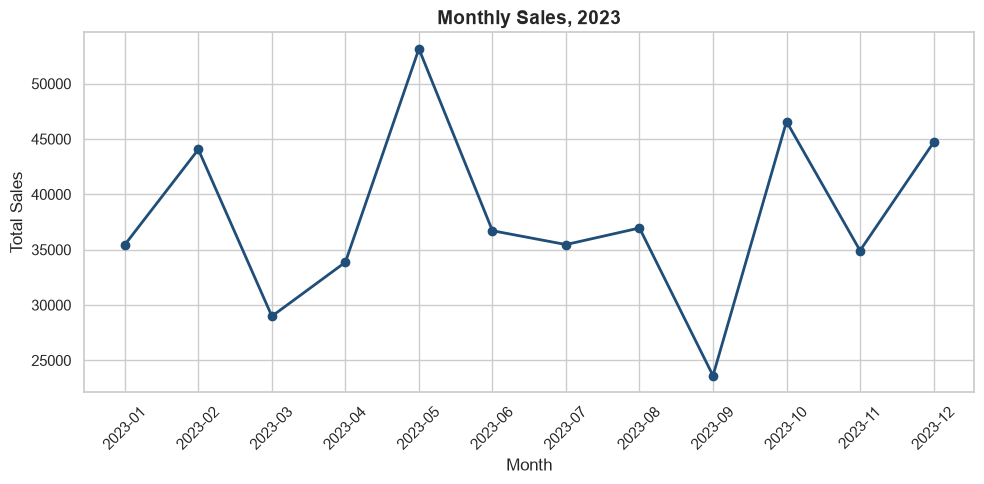

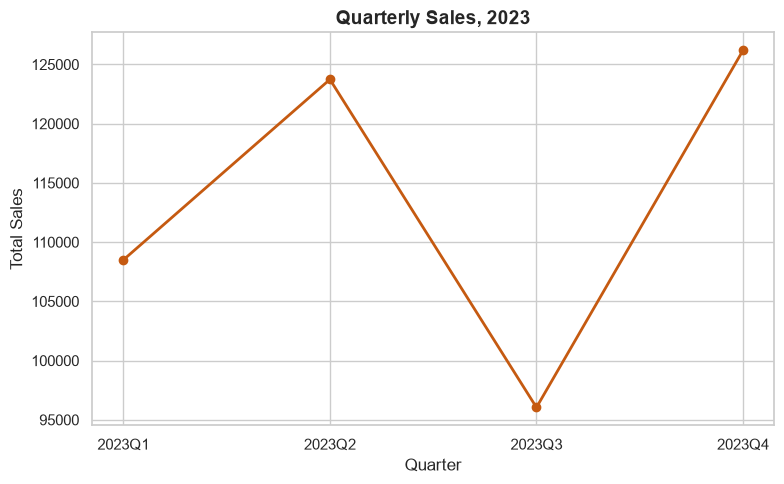

In [3]:
sns.set_theme(style="whitegrid")

sales_2023 = df[df["Date"] < "2024-01-01"]
monthly = sales_2023.groupby(sales_2023["Date"].dt.to_period("M"))["Total Amount"].sum()
quarterly = sales_2023.groupby(sales_2023["Date"].dt.to_period("Q"))["Total Amount"].sum()

print(monthly)
print(quarterly)

plt.figure(figsize=(10, 5))
plt.plot(monthly.index.astype(str), monthly.values, marker="o", color="#1f4e79", linewidth=2)
plt.title("Monthly Sales, 2023", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(quarterly.index.astype(str), quarterly.values, marker="o", color="#c55a11", linewidth=2)
plt.title("Quarterly Sales, 2023", fontsize=14, fontweight="bold")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

*Observations:* Sales peaked in May (53,150) and were lowest in September (23,620). Q4 was the strongest quarter (126,190) and Q3 the weakest (96,045). Sales swing from month to month instead of growing steadily. Two transactions dated 2024-01-01 were excluded so the trend covers 2023 only (998 of 1,000 rows)

Age Group
18-24    149
25-34    203
35-44    207
45-54    225
55-64    216
Name: count, dtype: int64
Gender
Female    510
Male      490
Name: count, dtype: int64
Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


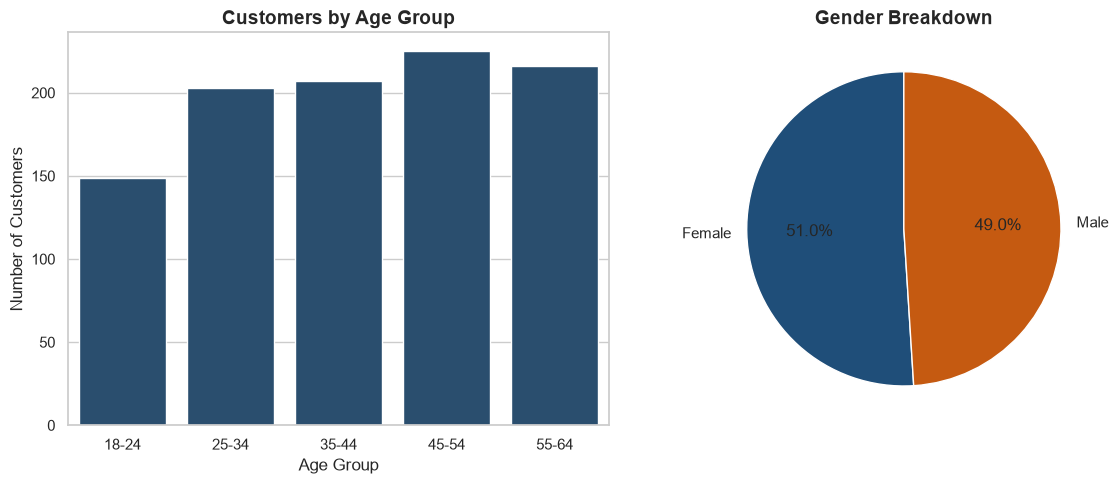

In [4]:
df["Age Group"] = pd.cut(df["Age"], bins=[17, 24, 34, 44, 54, 64],
                         labels=["18-24", "25-34", "35-44", "45-54", "55-64"])

age_counts = df["Age Group"].value_counts().sort_index()
gender_counts = df["Gender"].value_counts()

print(age_counts)
print(gender_counts)
print(df.groupby("Gender")["Total Amount"].sum())

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=age_counts.index.astype(str), y=age_counts.values, ax=ax[0], color="#1f4e79")
ax[0].set_title("Customers by Age Group", fontsize=14, fontweight="bold")
ax[0].set_xlabel("Age Group")
ax[0].set_ylabel("Number of Customers")

ax[1].pie(gender_counts.values, labels=gender_counts.index, autopct="%1.1f%%",
          colors=["#1f4e79", "#c55a11"], startangle=90)
ax[1].set_title("Gender Breakdown", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

*Observations:* Customers are spread fairly evenly across age groups. 45-54 is the largest group (225 customers) and 18-24 the smallest (149), which also spends the least (74,650). Gender is almost even: 51% female (510 customers, 232,840 in sales) and 49% male (490 customers, 223,160).

                  Revenue  Units  Transactions  Share %
Product Category                                       
Electronics        156905    849           342     34.4
Clothing           155580    894           351     34.1
Beauty             143515    771           307     31.5


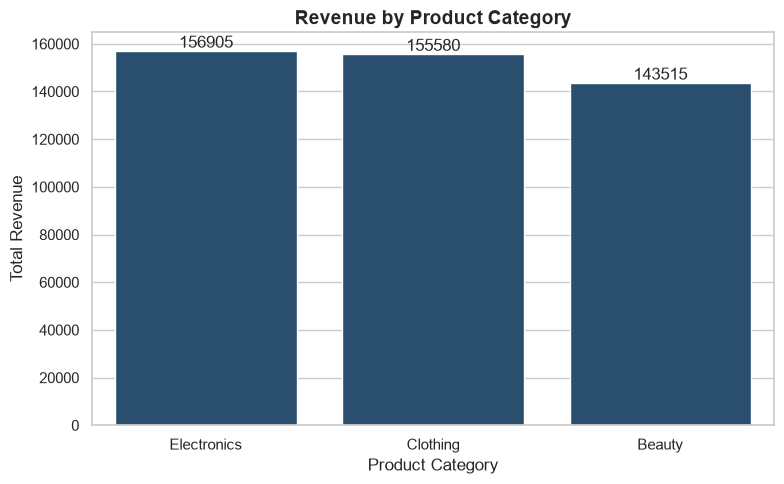

In [6]:
cat = df.groupby("Product Category").agg(
    Revenue=("Total Amount", "sum"),
    Units=("Quantity", "sum"),
    Transactions=("Transaction ID", "count"),
).sort_values("Revenue", ascending=False)
cat["Share %"] = (cat["Revenue"] / cat["Revenue"].sum() * 100).round(1)
print(cat)

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=cat.index, y=cat["Revenue"], color="#1f4e79")
for bars in ax.containers:
    ax.bar_label(bars, fmt="%d")
plt.title("Revenue by Product Category", fontsize=14, fontweight="bold")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

*Observations:* Electronics (156,905, 34.4%) and Clothing (155,580, 34.1%) are almost tied for revenue, and Beauty is lowest (143,515, 31.5%). Clothing sold the most units (894). The dataset has only 3 categories and no individual product names, so this category ranking replaces the "top 10 products" list

                 Age  Quantity  Price per Unit  Total Amount
Age             1.00     -0.02           -0.04         -0.06
Quantity       -0.02      1.00            0.02          0.37
Price per Unit -0.04      0.02            1.00          0.85
Total Amount   -0.06      0.37            0.85          1.00


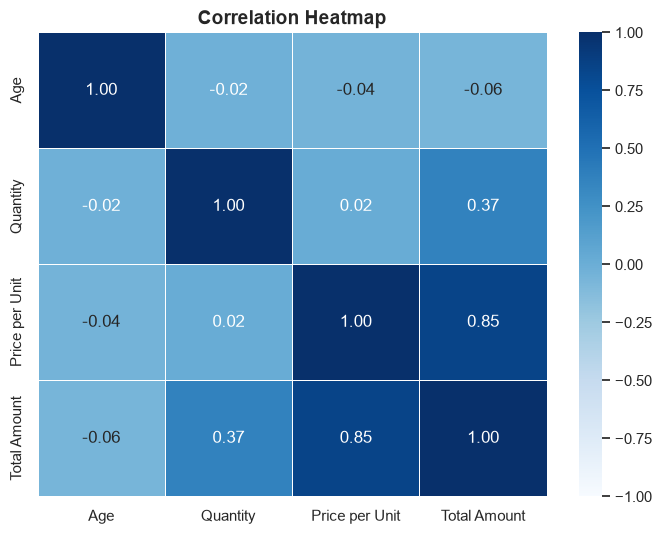

In [8]:
corr = df[["Age", "Quantity", "Price per Unit", "Total Amount"]].corr().round(2)
print(corr)

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, cmap="Blues", vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

*Observations:* Price per Unit has the strongest link to Total Amount (0.85). Quantity has a moderate link (0.37). Age has almost no link to spending (-0.06). Total Amount depends mostly on what is bought, not on how many items or who buys.

                Transactions  Revenue  Share of transactions %  Share of revenue %
Price per Unit                                                                    
25                       210    13050                     21.0                 2.9
30                       183    13350                     18.3                 2.9
50                       211    26700                     21.1                 5.9
300                      197   155400                     19.7                34.1
500                      199   247500                     19.9                54.3


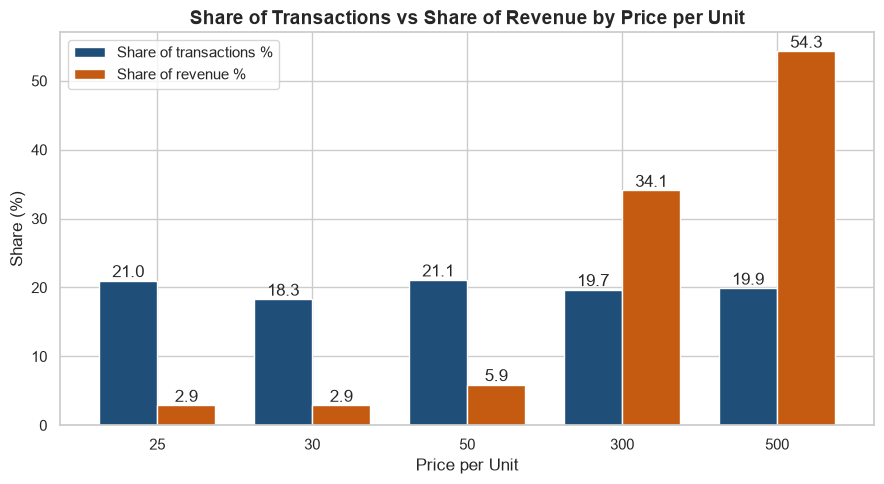

In [10]:
price = df.groupby("Price per Unit").agg(
    Transactions=("Transaction ID", "count"),
    Revenue=("Total Amount", "sum"),
)
price["Share of transactions %"] = (price["Transactions"] / price["Transactions"].sum() * 100).round(1)
price["Share of revenue %"] = (price["Revenue"] / price["Revenue"].sum() * 100).round(1)
print(price.to_string())

ax = price[["Share of transactions %", "Share of revenue %"]].plot(
    kind="bar", figsize=(9, 5), color=["#1f4e79", "#c55a11"], width=0.75)
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.1f")
plt.title("Share of Transactions vs Share of Revenue by Price per Unit", fontsize=14, fontweight="bold")
plt.xlabel("Price per Unit")
plt.ylabel("Share (%)")
plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()

*Observations:* The two highest price points (300 and 500) account for 39.6% of transactions but 88.4% of revenue. The three low price points (25, 30 and 50) account for 60.4% of transactions but only 11.6% of revenue. This is the key finding of the analysis

## Conclusion and Recommendations

Across 1,000 transactions (456,000 total revenue), the data shows three clear patterns. Recommendations:

1. *Focus on high-priced products.* The two highest price points (300 and 500) make up only 39.6% of transactions but 88.4% of revenue. Give them priority in stock, shelf space and promotions, and offer bundles that pair a low-priced item with a high-priced one.

2. *Plan around the sales swings.* September was the weakest month (23,620) and Q3 the weakest quarter (96,045), while May (53,150) and Q4 (126,190) were the strongest. Run promotions in September and Q3, and stock up ahead of May and Q4.

3. *Grow the weakest segments.* Customers aged 18-24 are the smallest group (149 customers, 74,650 in sales), and Beauty is the lowest category (143,515). Targeted campaigns for young shoppers and for Beauty would add growth at low risk, because gender and age otherwise show no big difference in spending.

Note: the dataset has no individual product names, so category-level analysis was used instead of a top 10 products list.